# Find Programmatic way to isolate peaks

Approach
- filter to just 0 - 1200 seconds
- bin data along the AP axis and find median fluorescence in each bin
- smooth the florescence data
- use scipy.signal.find_peaks to identify peaks and troughs
- for each peak, find the distance to the nearest trough and use peak +/- that distance as the ap range of the peak (this centers the peak within the range)

In [23]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import math as math
import seaborn as sns 

In [24]:

data_filtered = pd.read_csv('../../data/Berrocal_2020/Data/eve_data_longform_w_nuclei_060520_FILTERED.csv', header=0)
print(data_filtered)

        Unnamed: 0  nucleus_id  particle_id  set_id    ap_raw  ap_registered  \
0              192      1.0517          NaN       1  0.417799       0.412853   
1              193      1.0517          NaN       1  0.415974       0.411356   
2              194      1.0517          NaN       1  0.414500       0.410133   
3              195      1.0517          NaN       1  0.414155       0.410011   
4              196      1.0517          NaN       1  0.414665       0.410521   
...            ...         ...          ...     ...       ...            ...   
430068      497451     11.1492          NaN      11  0.274391       0.290641   
430069      497452     11.1492          NaN      11  0.274822       0.291048   
430070      497453     11.1492          NaN      11  0.275375       0.291569   
430071      497454     11.1492          NaN      11  0.276047       0.292204   
430072      497455     11.1492          NaN      11  0.276220       0.292367   

              xPos        yPos  burst_s

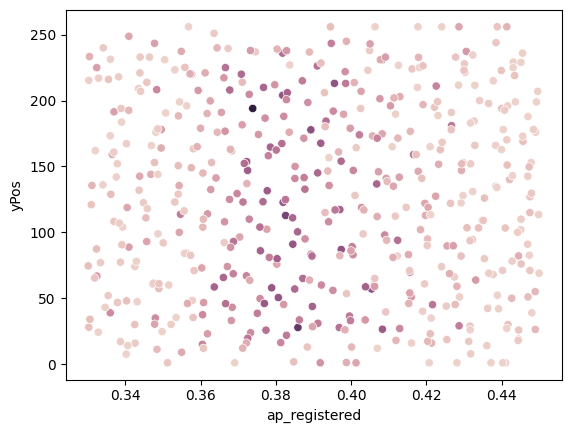

In [25]:
fluo_traces = data_filtered.pivot(index='nucleus_id', columns='time', values='fluo')
fluo_traces = fluo_traces.fillna(0)
fluo_traces.reset_index(inplace=True)

fluo_traces['sum_fluo'] = fluo_traces.iloc[:, 1:].sum(axis=1)

pos_data = data_filtered.drop(columns=['particle_id', 'set_id', 'ap_raw','burst_stripe_id', 'time', 'fluo',
       'inference_stripe_id', 'inference_fluo_id', 'v_state', 'v_fluo'])

# assign the nuclear position as the median position over the time window
pos_data = pos_data.groupby('nucleus_id').median()
pos_data.reset_index(inplace=True)

# filtering the nuclei for those in stripe 2 and the 1-2 and 2-3 interstripes
pos_data_str2 = pos_data[(pos_data['ap_registered']>0.33)& (pos_data['ap_registered']<0.45)]

pos_sum_df = fluo_traces.merge(pos_data_str2, on='nucleus_id')

sns.scatterplot(data=pos_sum_df, x="ap_registered", y="yPos", hue='sum_fluo', legend=False)
plt.show()
# sns.scatterplot(data=pos_sum_df, x="ap_registered", y="yPos", alpha=0.2, sizes=10, legend=False)
# plt.show()

/tmp/slurm.9665569/ipykernel_2864551/3524973849.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pos_data_str2['yPos_norm'] = ((pos_data_str2['yPos']-miny)/(maxy-miny))


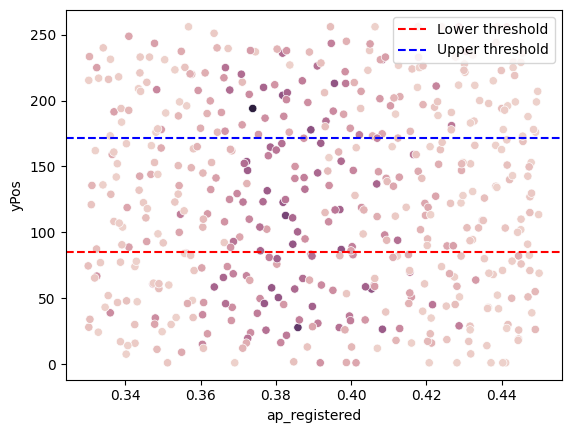

/tmp/slurm.9665569/ipykernel_2864551/3524973849.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pos_data_str2['yPos_norm'] = ((pos_data_str2['yPos']-miny)/(maxy-miny))


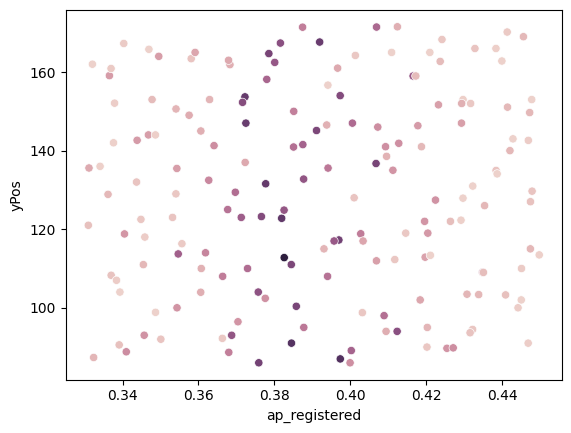

In [26]:
fluo_traces = data_filtered.pivot(index='nucleus_id', columns='time', values='fluo')
fluo_traces = fluo_traces.fillna(0)
fluo_traces.reset_index(inplace=True)

fluo_traces['sum_fluo'] = fluo_traces.iloc[:, 1:].sum(axis=1)

pos_data = data_filtered.drop(columns=['particle_id', 'set_id', 'ap_raw','burst_stripe_id', 'time', 'fluo',
       'inference_stripe_id', 'inference_fluo_id', 'v_state', 'v_fluo'])

# assign the nuclear position as the median position over the time window
pos_data = pos_data.groupby('nucleus_id').median()
pos_data.reset_index(inplace=True)

# filtering the nuclei for those in stripe 2 and the 1-2 and 2-3 interstripes
pos_data_str2 = pos_data[(pos_data['ap_registered']>0.33)& (pos_data['ap_registered']<0.45)]
miny = pos_data_str2['yPos'].min()
maxy = pos_data_str2['yPos'].max()
pos_data_str2['yPos_norm'] = ((pos_data_str2['yPos']-miny)/(maxy-miny))

# Compute threshold y positions
threshold_y_low = miny + 0.33 * (maxy - miny)
threshold_y_high = miny + 0.67 * (maxy - miny)

pos_sum_df = fluo_traces.merge(pos_data_str2, on='nucleus_id')

sns.scatterplot(data=pos_sum_df, x="ap_registered", y="yPos", hue='sum_fluo', legend=False)
plt.axhline(y=threshold_y_low, color='red', linestyle='--', label='Lower threshold')
plt.axhline(y=threshold_y_high, color='blue', linestyle='--', label='Upper threshold')
plt.legend()
plt.show()

pos_data_str2 = pos_data[(pos_data['ap_registered']>0.33)& (pos_data['ap_registered']<0.45)]
miny = pos_data_str2['yPos'].min()
maxy = pos_data_str2['yPos'].max()
pos_data_str2['yPos_norm'] = ((pos_data_str2['yPos']-miny)/(maxy-miny))
pos_data_str2 = pos_data_str2[(pos_data_str2['yPos_norm']>0.33)& (pos_data_str2['yPos_norm']<0.67)]

pos_sum_df = fluo_traces.merge(pos_data_str2, on='nucleus_id')

sns.scatterplot(data=pos_sum_df, x="ap_registered", y="yPos", hue='sum_fluo', legend=False)
plt.show()
# sns.scatterplot(data=pos_sum_df, x="ap_registered", y="yPos", alpha=0.2, sizes=10, legend=False)
# plt.show()

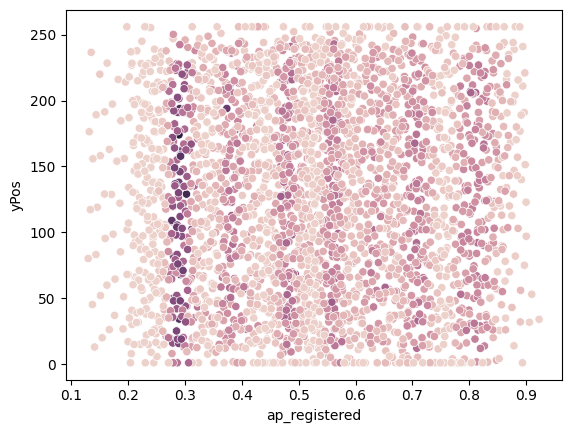

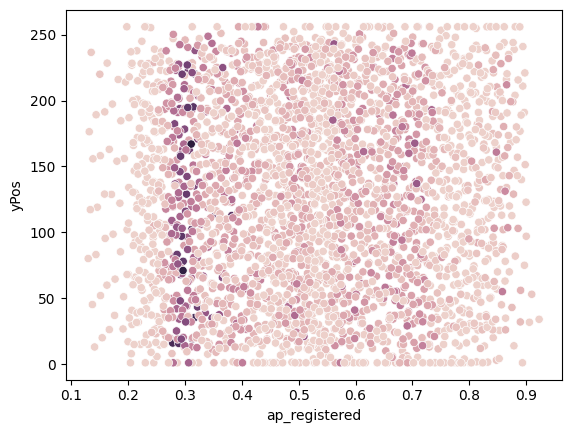

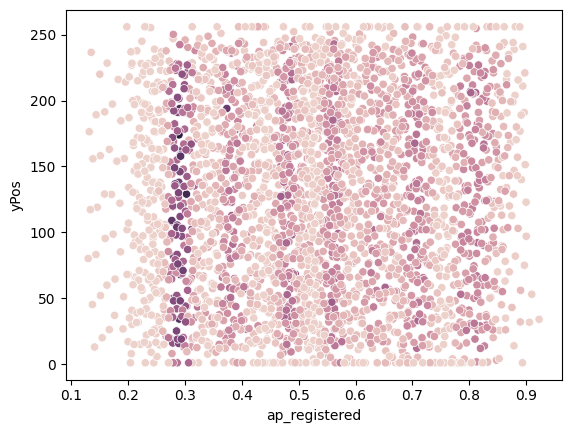

In [27]:
fluo_traces = data_filtered.pivot(index='nucleus_id', columns='time', values='fluo')
fluo_traces = fluo_traces.fillna(0)
fluo_traces.reset_index(inplace=True)

fluo_traces['sum_fluo'] = fluo_traces.iloc[:, 1:].sum(axis=1)
fluo_traces['sum_fluo_b41200'] = fluo_traces.iloc[:, 1:int(1200/20)+2].sum(axis=1)
fluo_traces['sum_fluo_after1200'] = fluo_traces.iloc[:, int(1200/20)+2:].sum(axis=1)

pos_data = data_filtered.drop(columns=['particle_id', 'set_id', 'ap_raw','burst_stripe_id', 'time', 'fluo',
       'inference_stripe_id', 'inference_fluo_id', 'v_state', 'v_fluo'])

# assign the nuclear position as the median position over the time window
pos_data = pos_data.groupby('nucleus_id').median()
pos_data.reset_index(inplace=True)

# filtering the nuclei for those in stripe 2 and the 1-2 and 2-3 interstripes
pos_data_str2 = pos_data#@[(pos_data['ap_registered']>0.33)& (pos_data['ap_registered']<0.45)]
pos_sum_df = fluo_traces.merge(pos_data_str2, on='nucleus_id')

sns.scatterplot(data=pos_sum_df, x="ap_registered", y="yPos", hue='sum_fluo', legend=False)
plt.show()
sns.scatterplot(data=pos_sum_df, x="ap_registered", y="yPos", hue='sum_fluo_b41200', legend=False)
plt.show()
sns.scatterplot(data=pos_sum_df, x="ap_registered", y="yPos", hue='sum_fluo_after1200', legend=False)
plt.show()

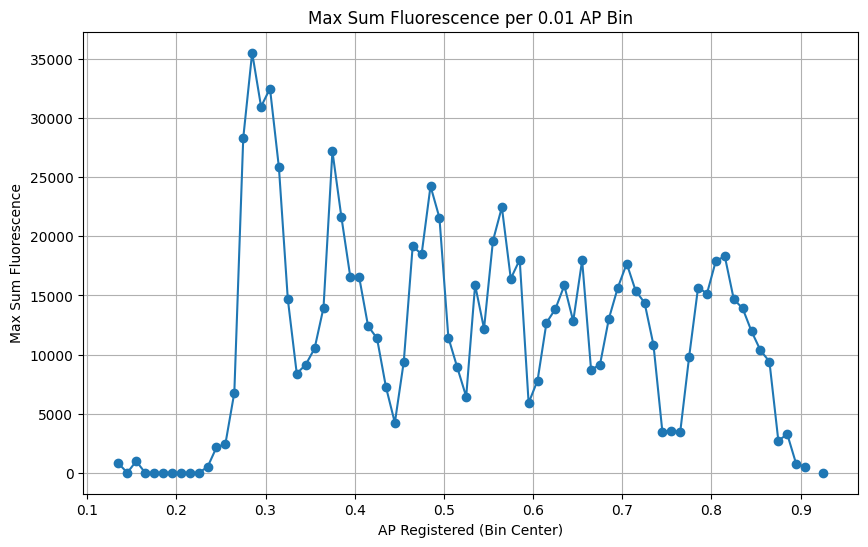

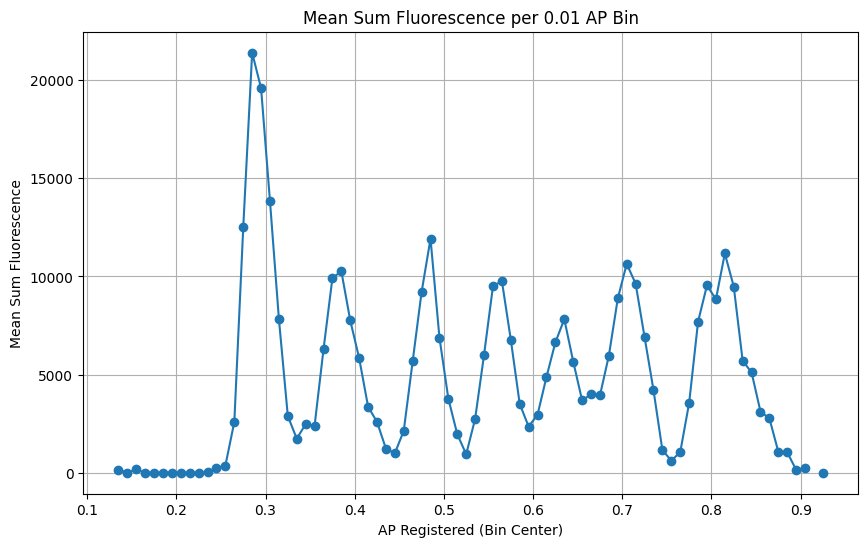

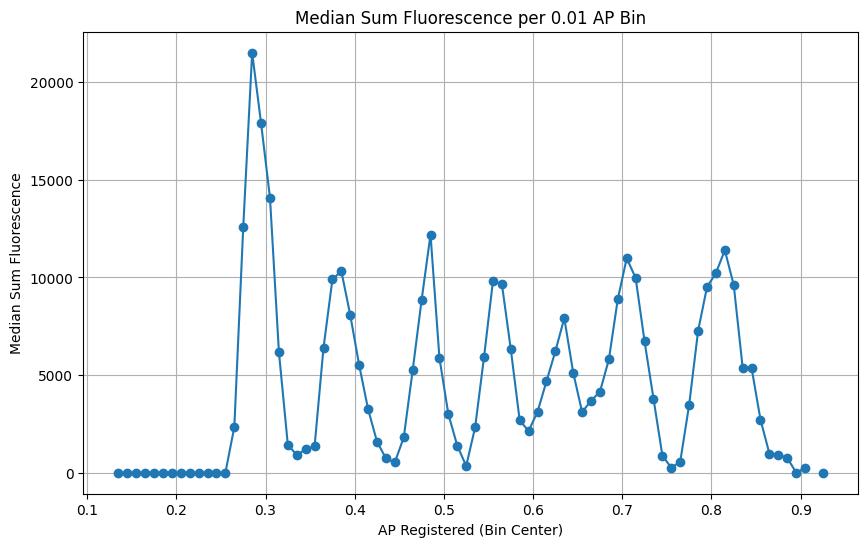

In [16]:
import numpy as np

# Define bin edges for ap_registered from min to max in steps of 0.01
min_ap = pos_sum_df['ap_registered'].min()
max_ap = pos_sum_df['ap_registered'].max()
BIN_SIZE = 0.01
bins = np.arange(min_ap, max_ap + BIN_SIZE, BIN_SIZE)

# Bin the data and find max sum_fluo per bin
pos_sum_df['ap_bin'] = pd.cut(pos_sum_df['ap_registered'], bins)
binned_max = pos_sum_df.groupby('ap_bin')['sum_fluo'].max().reset_index()

# Calculate bin centers for plotting
binned_max['ap_bin_center'] = binned_max['ap_bin'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(binned_max['ap_bin_center'], binned_max['sum_fluo'], marker='o', linestyle='-')
plt.xlabel('AP Registered (Bin Center)')
plt.ylabel('Max Sum Fluorescence')
plt.title('Max Sum Fluorescence per 0.01 AP Bin')
plt.grid(True)
plt.show()

# Bin the data and find mean sum_fluo per bin
pos_sum_df['ap_bin'] = pd.cut(pos_sum_df['ap_registered'], bins)
binned_mean = pos_sum_df.groupby('ap_bin')['sum_fluo'].mean().reset_index()

# Calculate bin centers for plotting
binned_mean['ap_bin_center'] = binned_mean['ap_bin'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(binned_mean['ap_bin_center'], binned_mean['sum_fluo'], marker='o', linestyle='-')
plt.xlabel('AP Registered (Bin Center)')
plt.ylabel('Mean Sum Fluorescence')
plt.title('Mean Sum Fluorescence per 0.01 AP Bin')
plt.grid(True)
plt.show()

# Bin the data and find mean sum_fluo per bin
pos_sum_df['ap_bin'] = pd.cut(pos_sum_df['ap_registered'], bins)
binned_median = pos_sum_df.groupby('ap_bin')['sum_fluo'].median().reset_index()

# Calculate bin centers for plotting
binned_median['ap_bin_center'] = binned_median['ap_bin'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(binned_median['ap_bin_center'], binned_median['sum_fluo'], marker='o', linestyle='-')
plt.xlabel('AP Registered (Bin Center)')
plt.ylabel('Median Sum Fluorescence')
plt.title('Median Sum Fluorescence per 0.01 AP Bin')
plt.grid(True)
plt.show()

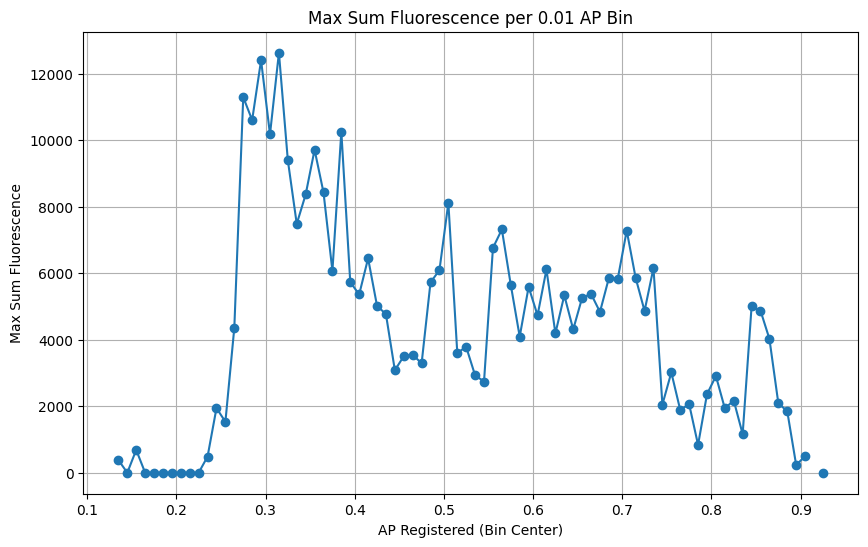

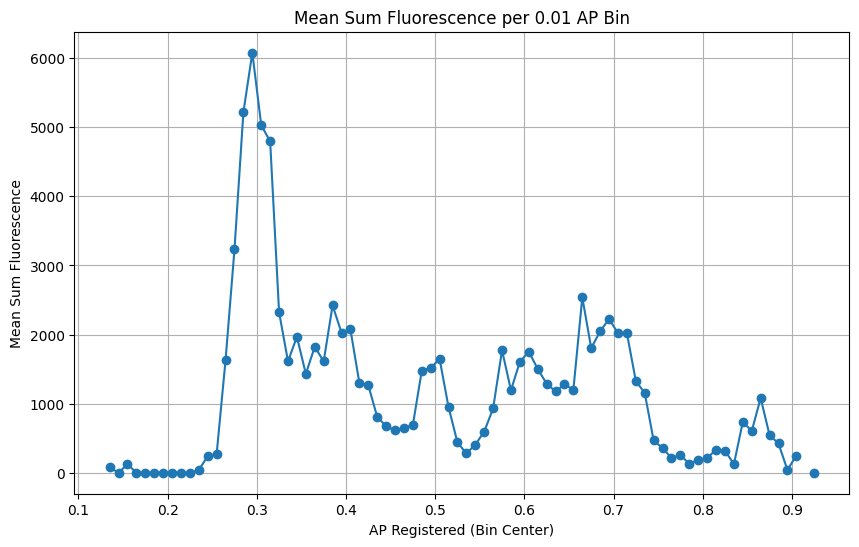

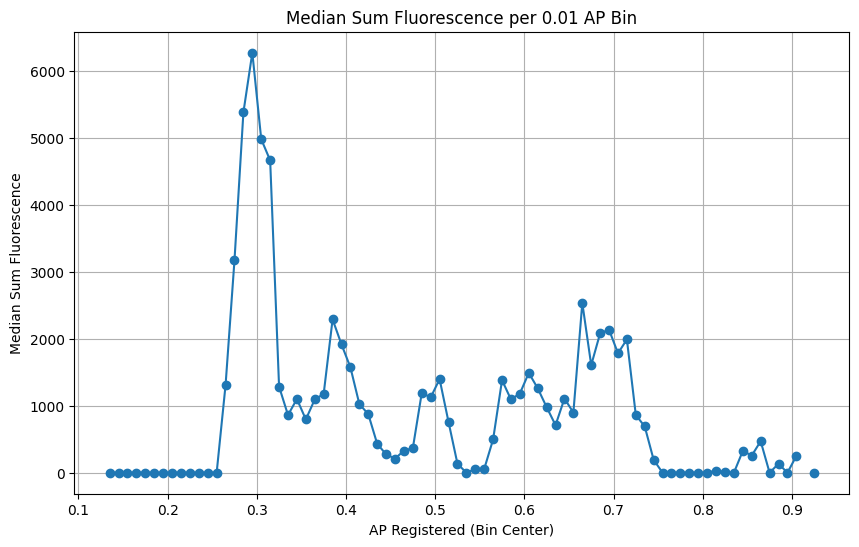

In [28]:
import numpy as np

# Define bin edges for ap_registered from min to max in steps of 0.01
min_ap = pos_sum_df['ap_registered'].min()
max_ap = pos_sum_df['ap_registered'].max()
BIN_SIZE = 0.01
bins = np.arange(min_ap, max_ap + BIN_SIZE, BIN_SIZE)

# Bin the data and find max sum_fluo per bin
pos_sum_df['ap_bin'] = pd.cut(pos_sum_df['ap_registered'], bins)
binned_max = pos_sum_df.groupby('ap_bin')['sum_fluo_b41200'].max().reset_index()

# Calculate bin centers for plotting
binned_max['ap_bin_center'] = binned_max['ap_bin'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(binned_max['ap_bin_center'], binned_max['sum_fluo_b41200'], marker='o', linestyle='-')
plt.xlabel('AP Registered (Bin Center)')
plt.ylabel('Max Sum Fluorescence')
plt.title('Max Sum Fluorescence per 0.01 AP Bin')
plt.grid(True)
plt.show()

# Bin the data and find mean sum_fluo per bin
pos_sum_df['ap_bin'] = pd.cut(pos_sum_df['ap_registered'], bins)
binned_mean = pos_sum_df.groupby('ap_bin')['sum_fluo_b41200'].mean().reset_index()

# Calculate bin centers for plotting
binned_mean['ap_bin_center'] = binned_mean['ap_bin'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(binned_mean['ap_bin_center'], binned_mean['sum_fluo_b41200'], marker='o', linestyle='-')
plt.xlabel('AP Registered (Bin Center)')
plt.ylabel('Mean Sum Fluorescence')
plt.title('Mean Sum Fluorescence per 0.01 AP Bin')
plt.grid(True)
plt.show()

# Bin the data and find mean sum_fluo per bin
pos_sum_df['ap_bin'] = pd.cut(pos_sum_df['ap_registered'], bins)
binned_median = pos_sum_df.groupby('ap_bin')['sum_fluo_b41200'].median().reset_index()

# Calculate bin centers for plotting
binned_median['ap_bin_center'] = binned_median['ap_bin'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(binned_median['ap_bin_center'], binned_median['sum_fluo_b41200'], marker='o', linestyle='-')
plt.xlabel('AP Registered (Bin Center)')
plt.ylabel('Median Sum Fluorescence')
plt.title('Median Sum Fluorescence per 0.01 AP Bin')
plt.grid(True)
plt.show()


Intel MKL ERROR: Parameter 6 was incorrect on entry to DGELSD.

Intel MKL ERROR: Parameter 6 was incorrect on entry to DGELSD.
Used moving average for smoothing.
Final smoothing method used: moving average (window=5)
Peak 1: AP range from 0.2350 to 0.3550, centered at 0.2950
Peak 2: AP range from 0.3550 to 0.4150, centered at 0.3850
Peak 3: AP range from 0.4550 to 0.5350, centered at 0.4950
Peak 4: AP range from 0.5550 to 0.6350, centered at 0.5950
Peak 5: AP range from 0.6350 to 0.7350, centered at 0.6850
Peak 6: AP range from 0.8050 to 0.9250, centered at 0.8650


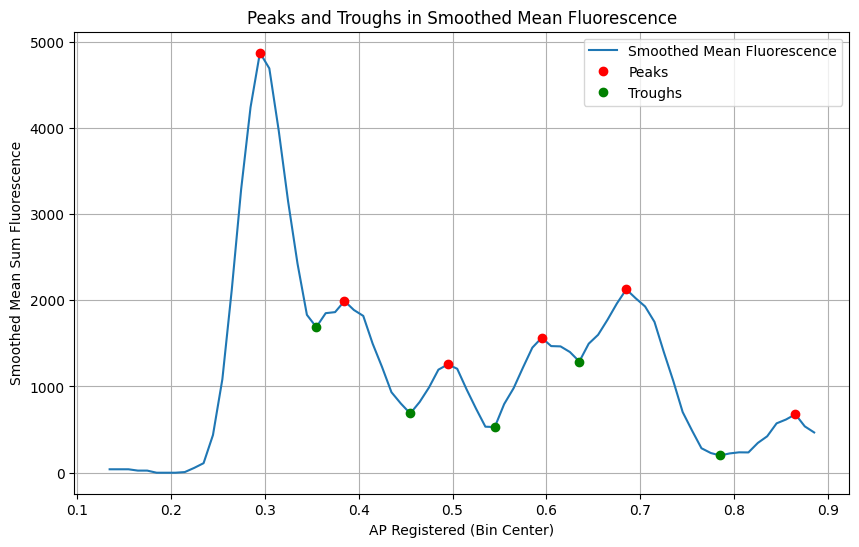

In [29]:
import scipy.signal as signal

# Assuming binned_mean is already defined from previous cells
# Smooth the mean fluorescence data using multiple methods for better peak detection
smoothed_fluo = None
# Assuming binned_mean is already defined from previous cells
# Smooth the mean fluorescence data using multiple methods for better peak detection
smoothed_fluo = None
smoothing_method = "none"

try:
    smoothed_fluo = signal.savgol_filter(binned_mean['sum_fluo_b41200'], window_length=5, polyorder=3)
    smoothing_method = "Savitzky-Golay (window=11, poly=3)"
    print("Used Savitzky-Golay filter for smoothing.")
except np.linalg.LinAlgError:
    try:
        # Try Savitzky-Golay with different parameters
        smoothed_fluo = signal.savgol_filter(binned_mean['sum_fluo_b41200'], window_length=5, polyorder=2)
        smoothing_method = "Savitzky-Golay (window=9, poly=2)"
        print("Used alternative Savitzky-Golay parameters for smoothing.")
    except np.linalg.LinAlgError:
        try:
            # Try a simple moving average
            window = 5
            smoothed_fluo = np.convolve(binned_mean['sum_fluo_b41200'], np.ones(window)/window, mode='same')
            smoothing_method = f"moving average (window={window})"
            print(f"Used moving average for smoothing.")
        except Exception:
            # Fallback to original data
            smoothed_fluo = binned_mean['sum_fluo_b41200'].values
            smoothing_method = "original data (smoothing failed)"
            print("Smoothing failed; using original data.")

print(f"Final smoothing method used: {smoothing_method}")

# Find peaks in the smoothed data
peaks, _ = signal.find_peaks(smoothed_fluo, prominence=200)  # Adjust prominence as needed

# Find troughs by inverting the data
troughs, _ = signal.find_peaks(-smoothed_fluo, prominence=200)

# For each peak, find the nearest troughs on left and right
ap_centers = binned_median['ap_bin_center'].values
peak_ranges_closestTrough = []
peak_ranges_troughs = []
for peak_idx in peaks:
    peak_ap = ap_centers[peak_idx]
    # Find nearest left trough
    left_troughs = troughs[troughs < peak_idx]
    if len(left_troughs) > 0:
        left_trough_idx = left_troughs[-1]
        left_ap = ap_centers[left_trough_idx]
    else:
        left_ap = ap_centers[0]  # Start of data
    # Find nearest right trough
    right_troughs = troughs[troughs > peak_idx]
    if len(right_troughs) > 0:
        right_trough_idx = right_troughs[0]
        right_ap = ap_centers[right_trough_idx]
    else:
        right_ap = ap_centers[-1]  # End of data
    # Center the peak and cut off at troughs
    center_ap = peak_ap
    if center_ap - left_ap > right_ap - center_ap:
        left_cutoff = center_ap - (right_ap - center_ap)
        right_cutoff = right_ap
    else:
        right_cutoff = center_ap + (center_ap - left_ap)
        left_cutoff = left_ap

    peak_ranges_closestTrough.append((left_cutoff, center_ap, right_cutoff))
    peak_ranges_troughs.append((left_ap, center_ap, right_ap))

# Print the AP registered ranges for each peak
for i, (left, center, right) in enumerate(peak_ranges_closestTrough):
    print(f"Peak {i+1}: AP range from {left:.4f} to {right:.4f}, centered at {center:.4f}")

# Optional: Plot the smoothed data with peaks and troughs marked
plt.figure(figsize=(10, 6))
plt.plot(ap_centers, smoothed_fluo, label='Smoothed Mean Fluorescence')
plt.plot(ap_centers[peaks], smoothed_fluo[peaks], 'ro', label='Peaks')
plt.plot(ap_centers[troughs], smoothed_fluo[troughs], 'go', label='Troughs')
plt.xlabel('AP Registered (Bin Center)')
plt.ylabel('Smoothed Mean Sum Fluorescence')
plt.title('Peaks and Troughs in Smoothed Mean Fluorescence')
plt.legend()
plt.grid(True)
plt.show()


Intel MKL ERROR: Parameter 6 was incorrect on entry to DGELSD.
Used moving average for smoothing.
Final smoothing method used: moving average (window=5)
Peak 1: AP range from 0.2475 to 0.3375, centered at 0.2925
Peak 2: AP range from 0.3375 to 0.4275, centered at 0.3825
Peak 3: AP range from 0.4425 to 0.5225, centered at 0.4825
Peak 4: AP range from 0.5325 to 0.5925, centered at 0.5625
Peak 5: AP range from 0.6025 to 0.6625, centered at 0.6325
Peak 6: AP range from 0.6625 to 0.7525, centered at 0.7075
Peak 7: AP range from 0.7575 to 0.8775, centered at 0.8175

Intel MKL ERROR: Parameter 6 was incorrect on entry to DGELSD.


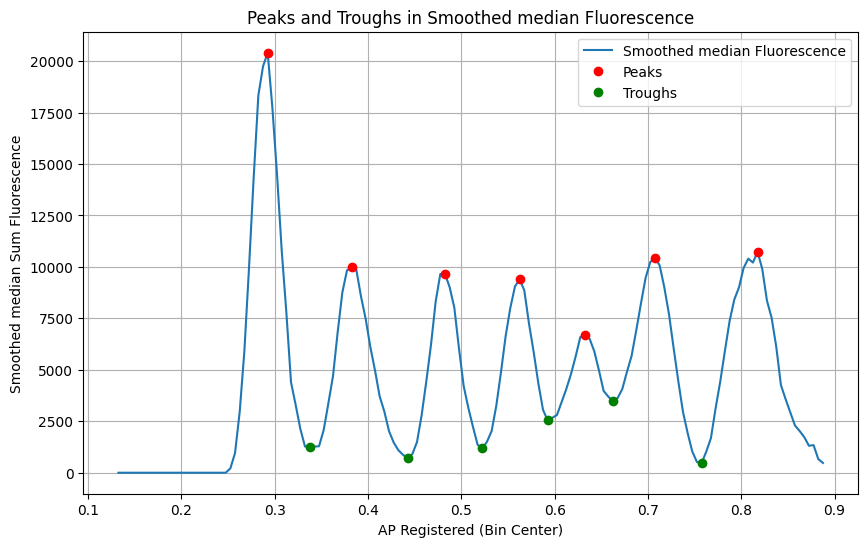

In [ ]:
import scipy.signal as signal

# Assuming binned_median is already defined from previous cells
# Smooth the median fluorescence data using multiple methods for better peak detection
smoothed_fluo = None
# Assuming binned_median is already defined from previous cells
# Smooth the median fluorescence data using multiple methods for better peak detection
smoothed_fluo = None
smoothing_method = "none"

try:
    smoothed_fluo = signal.savgol_filter(binned_median['sum_fluo'], window_length=11, polyorder=3)
    smoothing_method = "Savitzky-Golay (window=11, poly=3)"
    print("Used Savitzky-Golay filter for smoothing.")
except np.linalg.LinAlgError:
    try:
        # Try Savitzky-Golay with different parameters
        smoothed_fluo = signal.savgol_filter(binned_median['sum_fluo'], window_length=9, polyorder=2)
        smoothing_method = "Savitzky-Golay (window=9, poly=2)"
        print("Used alternative Savitzky-Golay parameters for smoothing.")
    except np.linalg.LinAlgError:
        try:
            # Try a simple moving average
            smoothed_fluo = np.convolve(binned_median['sum_fluo'], np.ones(5)/5, mode='same')
            smoothing_method = "moving average (window=5)"
            print("Used moving average for smoothing.")
        except Exception:
            # Fallback to original data
            smoothed_fluo = binned_median['sum_fluo'].values
            smoothing_method = "original data (smoothing failed)"
            print("Smoothing failed; using original data.")

print(f"Final smoothing method used: {smoothing_method}")

# Find peaks in the smoothed data
peaks, _ = signal.find_peaks(smoothed_fluo, prominence=1000)  # Adjust prominence as needed

# Find troughs by inverting the data
troughs, _ = signal.find_peaks(-smoothed_fluo, prominence=1000)

# For each peak, find the nearest troughs on left and right
ap_centers = binned_median['ap_bin_center'].values
peak_ranges_closestTrough = []
peak_ranges_troughs = []
for peak_idx in peaks:
    peak_ap = ap_centers[peak_idx]
    # Find nearest left trough
    left_troughs = troughs[troughs < peak_idx]
    if len(left_troughs) > 0:
        left_trough_idx = left_troughs[-1]
        left_ap = ap_centers[left_trough_idx]
    else:
        left_ap = ap_centers[0]  # Start of data
    # Find nearest right trough
    right_troughs = troughs[troughs > peak_idx]
    if len(right_troughs) > 0:
        right_trough_idx = right_troughs[0]
        right_ap = ap_centers[right_trough_idx]
    else:
        right_ap = ap_centers[-1]  # End of data
    # Center the peak and cut off at troughs
    center_ap = peak_ap
    if center_ap - left_ap > right_ap - center_ap:
        left_cutoff = center_ap - (right_ap - center_ap)
        right_cutoff = right_ap
    else:
        right_cutoff = center_ap + (center_ap - left_ap)
        left_cutoff = left_ap

    peak_ranges_closestTrough.append((left_cutoff, center_ap, right_cutoff))
    peak_ranges_troughs.append((left_ap, center_ap, right_ap))

# Print the AP registered ranges for each peak
for i, (left, center, right) in enumerate(peak_ranges_closestTrough):
    print(f"Peak {i+1}: AP range from {left:.4f} to {right:.4f}, centered at {center:.4f}")

# Optional: Plot the smoothed data with peaks and troughs marked
plt.figure(figsize=(10, 6))
plt.plot(ap_centers, smoothed_fluo, label='Smoothed median Fluorescence')
plt.plot(ap_centers[peaks], smoothed_fluo[peaks], 'ro', label='Peaks')
plt.plot(ap_centers[troughs], smoothed_fluo[troughs], 'go', label='Troughs')
plt.xlabel('AP Registered (Bin Center)')
plt.ylabel('Smoothed median Sum Fluorescence')
plt.title('Peaks and Troughs in Smoothed median Fluorescence')
plt.legend()
plt.grid(True)
plt.show()

<-Filtering for nuclei in peak 1 range: 0.235 to 0.355
Filtering for nuclei in peak 1 range: 0.135 to 0.355->


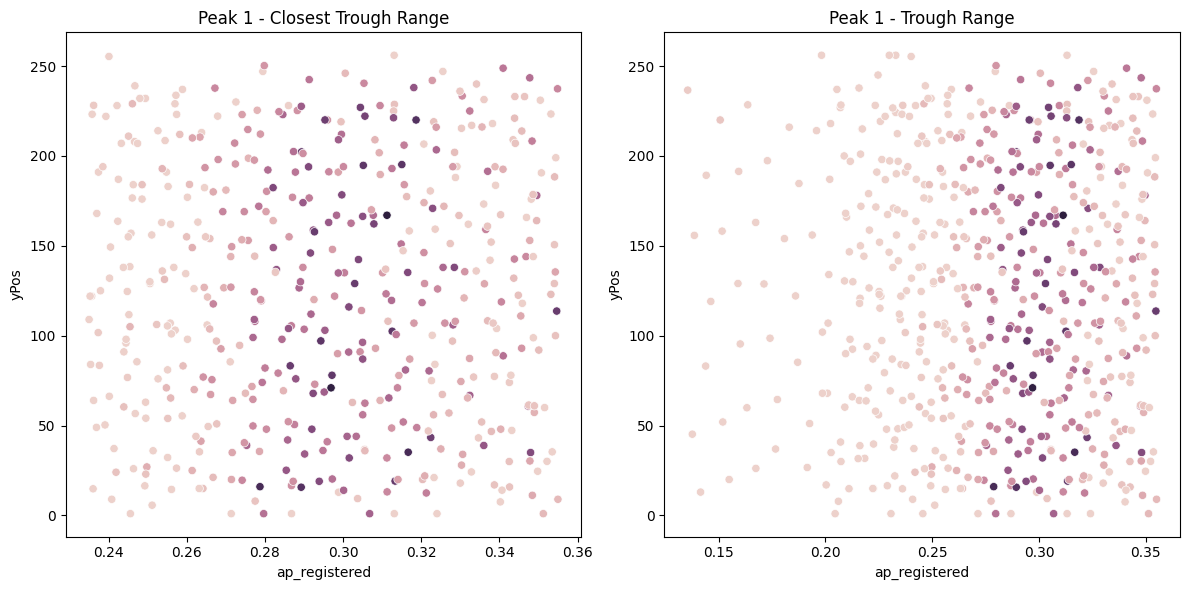

<-Filtering for nuclei in peak 2 range: 0.355 to 0.41500000000000004
Filtering for nuclei in peak 2 range: 0.355 to 0.455->


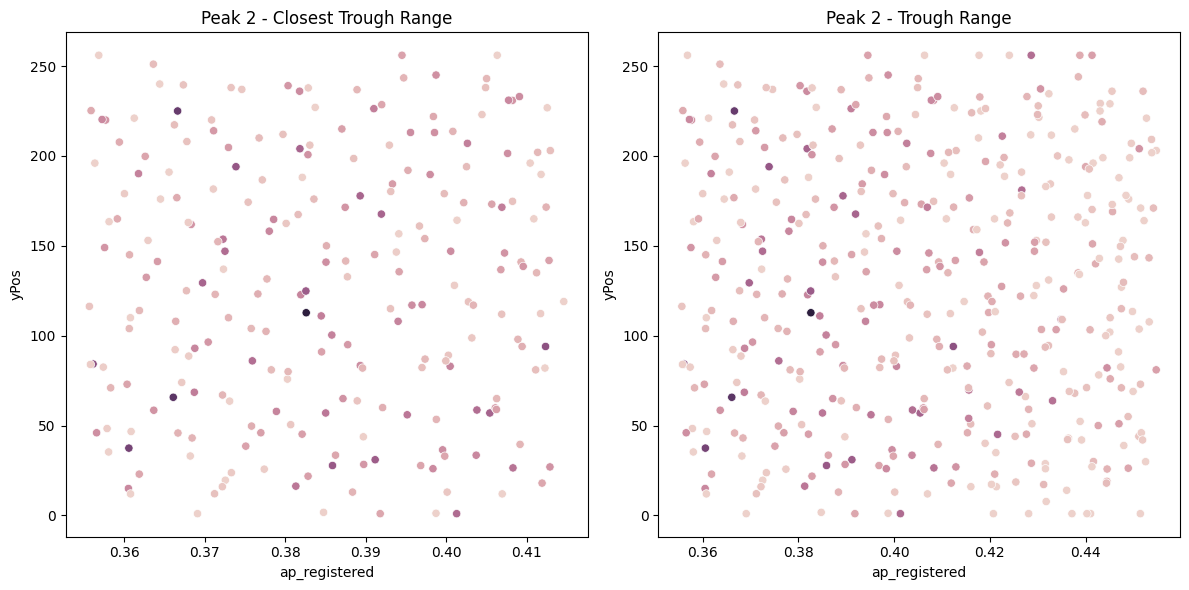

<-Filtering for nuclei in peak 3 range: 0.455 to 0.5349999999999999
Filtering for nuclei in peak 3 range: 0.455 to 0.545->


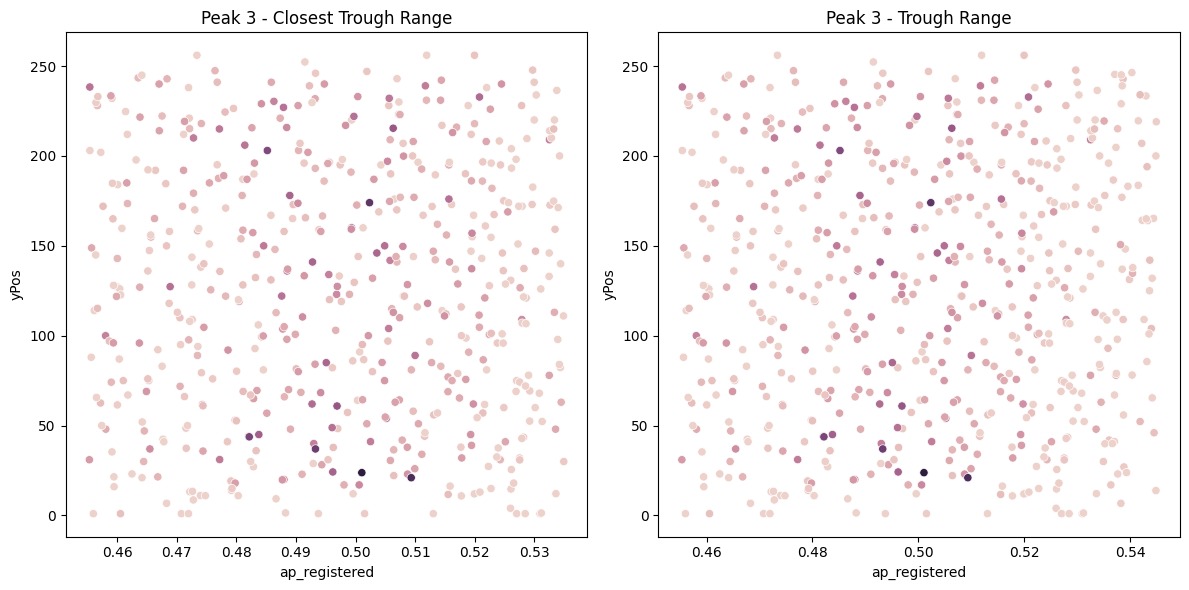

<-Filtering for nuclei in peak 4 range: 0.5549999999999999 to 0.635
Filtering for nuclei in peak 4 range: 0.545 to 0.635->


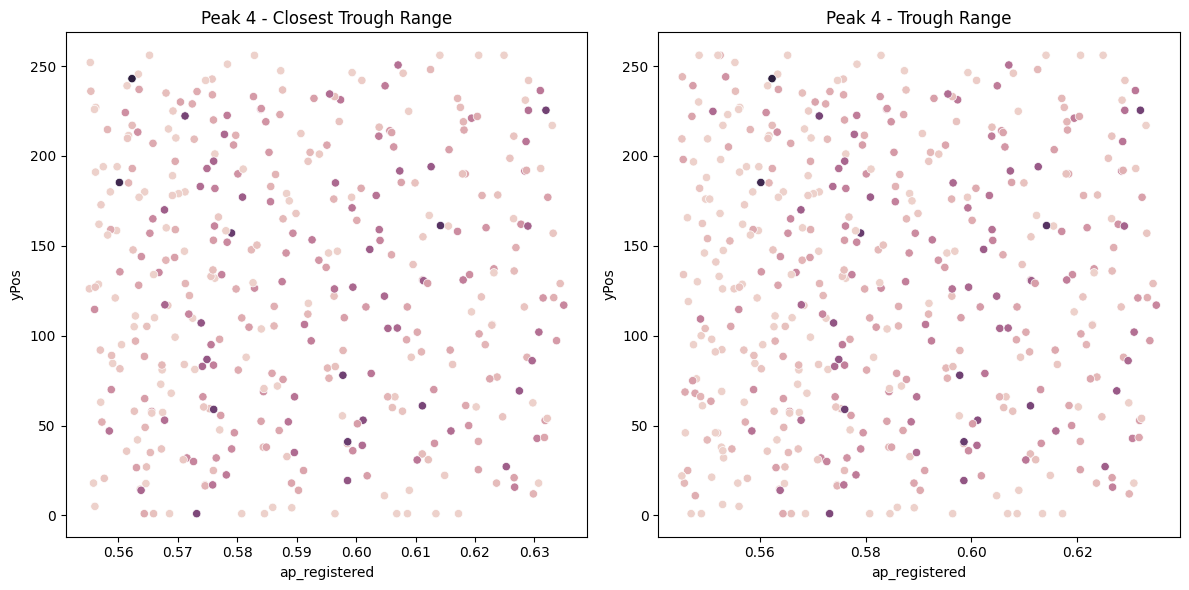

<-Filtering for nuclei in peak 5 range: 0.635 to 0.7350000000000001
Filtering for nuclei in peak 5 range: 0.635 to 0.785->


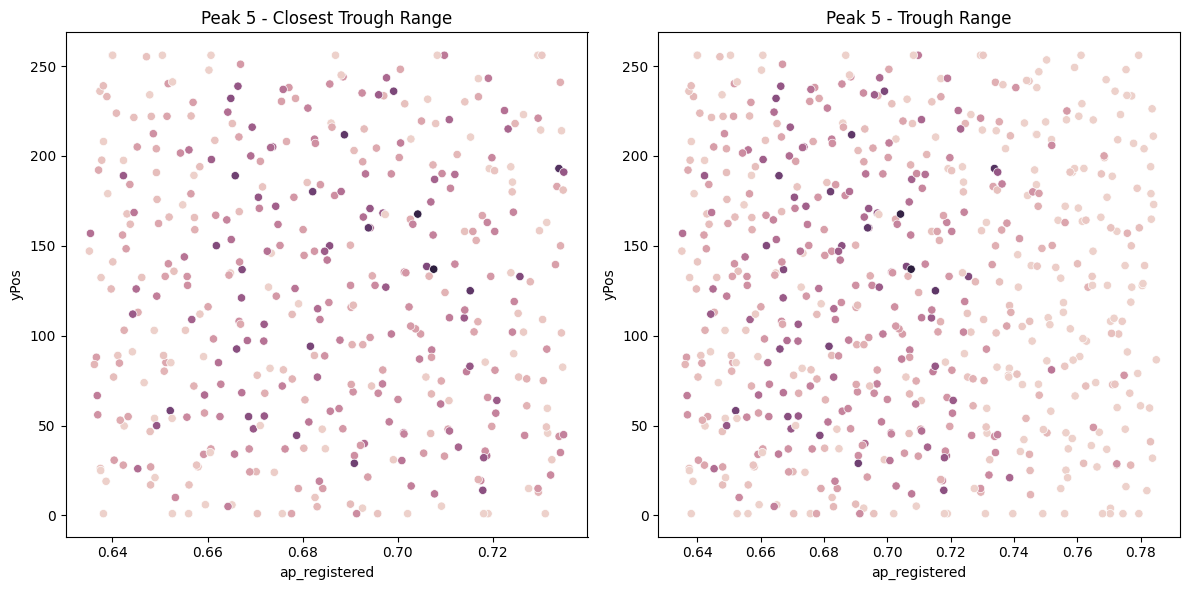

<-Filtering for nuclei in peak 6 range: 0.8049999999999999 to 0.925
Filtering for nuclei in peak 6 range: 0.785 to 0.925->


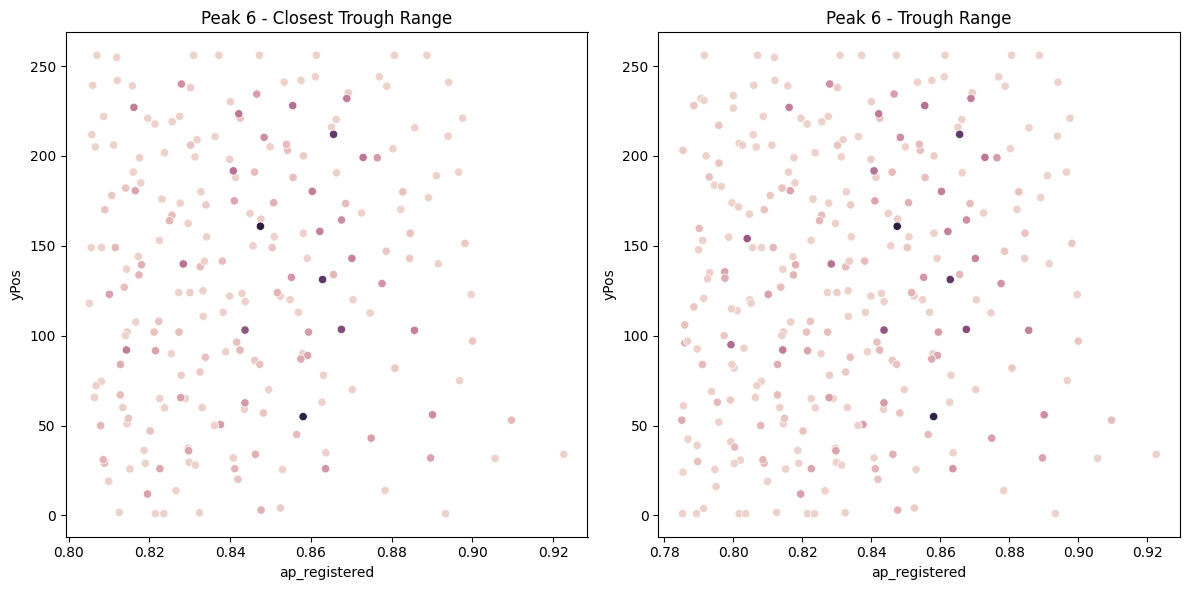

In [21]:
for i in range(len(peak_ranges_closestTrough)):
    print(f"<-Filtering for nuclei in peak {i+1} range: {peak_ranges_closestTrough[i][0]} to {peak_ranges_closestTrough[i][2]}")
    print(f"Filtering for nuclei in peak {i+1} range: {peak_ranges_troughs[i][0]} to {peak_ranges_troughs[i][2]}->")
    # filtering the nuclei for those in stripe 2
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    pos_data_str2 = pos_data[(pos_data['ap_registered']>peak_ranges_closestTrough[i][0])& (pos_data['ap_registered']<peak_ranges_closestTrough[i][2])]
    pos_sum_df = fluo_traces.merge(pos_data_str2, on='nucleus_id')
    sns.scatterplot(data=pos_sum_df, x="ap_registered", y="yPos", hue='sum_fluo_b41200', legend=False, ax=axes[0])
    axes[0].set_title(f'Peak {i+1} - Closest Trough Range')
    
    pos_data_str2 = pos_data[(pos_data['ap_registered']>peak_ranges_troughs[i][0])& (pos_data['ap_registered']<peak_ranges_troughs[i][2])]
    pos_sum_df = fluo_traces.merge(pos_data_str2, on='nucleus_id')
    sns.scatterplot(data=pos_sum_df, x="ap_registered", y="yPos", hue='sum_fluo_b41200', legend=False, ax=axes[1])
    axes[1].set_title(f'Peak {i+1} - Trough Range')
    
    plt.tight_layout()
    plt.show()